In [1]:
import cv2 as cv
import numpy as np
import supervision as sv
import matplotlib.pyplot as plt

**Preprocesamos coca_multi.png**

Dado que los logos en la imagen son pequeños la ampliamos para no tener que reducir tanto el pattern.

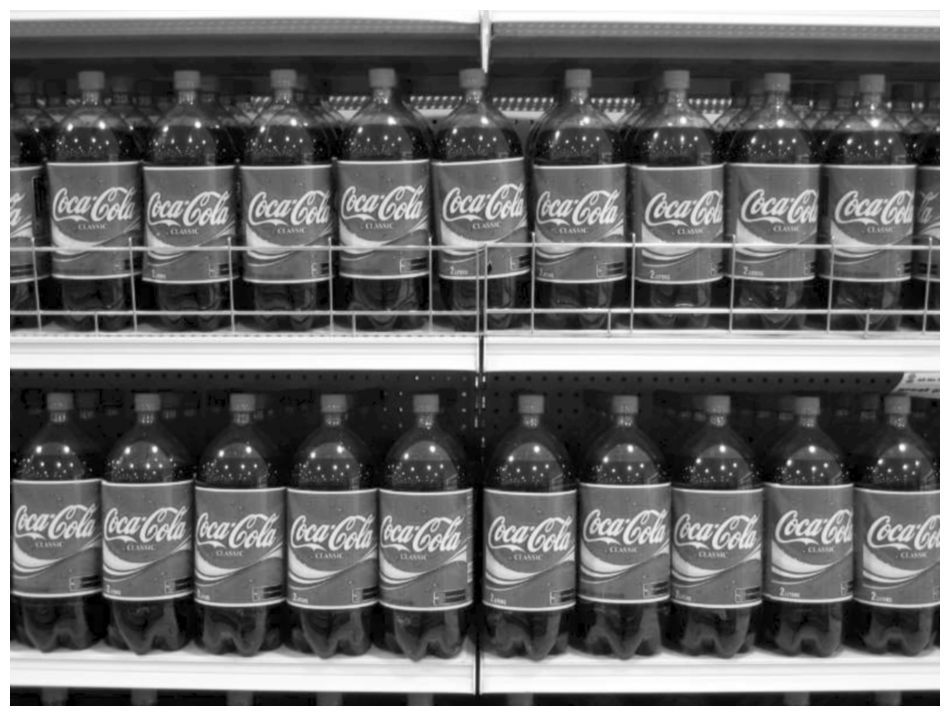

Medidas de la imagen: (1196, 1598)


In [2]:
# Cargamos coca_multi.png
img2 = cv.imread('images/coca_multi.png', cv.IMREAD_GRAYSCALE)

# Le hacemos un resizing + blur para no tener que achicar tanto el pattern
img2_resized = cv.resize(img2, None, fx=2, fy=2)
img2_proc = cv.GaussianBlur(img2_resized, (3, 3), 0)
sv.plot_image(img2_proc)

print('Medidas de la imagen:', img2_proc.shape)

**Preprocesamiento del pattern**

Dado que el pattern no de repite igual en todas las botellas recortamos los extremos y nos quedamos con el centro del logo para mejorar el matching. Pasamos el pattern a su versión negativa para que coincida con la imagen de destino.

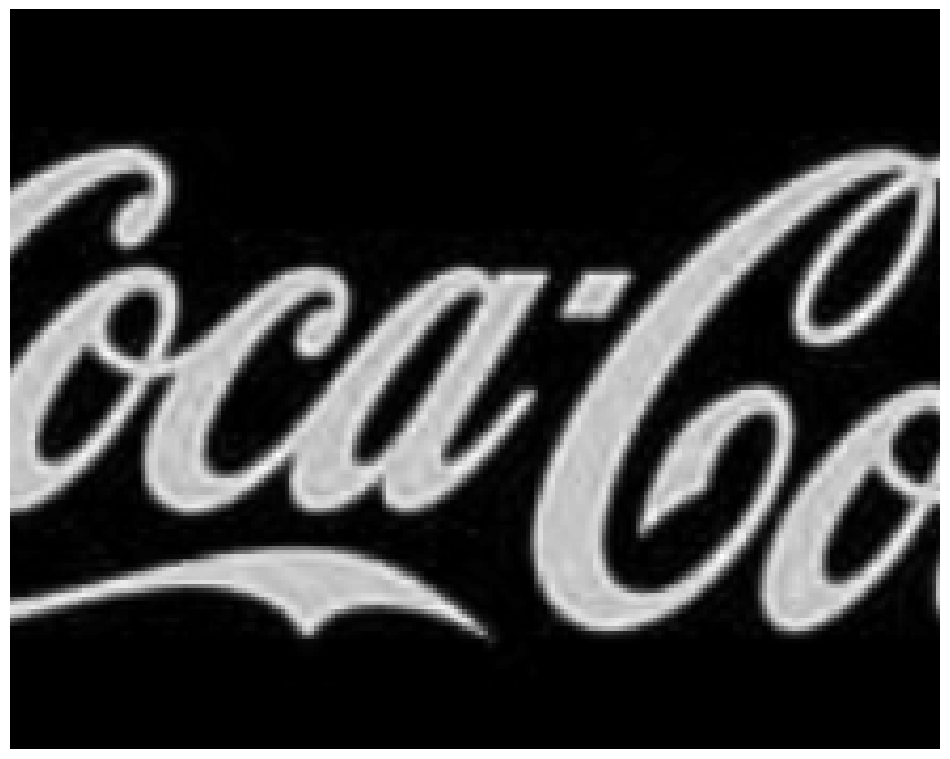

In [3]:
patt_orig = cv.imread('template/pattern.png', cv.IMREAD_GRAYSCALE)

crop_left = 60
crop_right = 120

h, w = patt_orig.shape

patt_crop = patt_orig[:, crop_left:w - crop_right]
pattern = cv.bitwise_not(patt_crop)

sv.plot_image(pattern)

In [4]:
# Armamos la función de resizing y blureado posterior
def scale_img(img, min, max, levels):
    scales = np.linspace(min, max, levels)
    processed_imgs = list()

    for scale in scales:
        resized_img = cv.resize(img, None, fx=scale, fy=scale)
        processed_img = cv.GaussianBlur(resized_img, (3, 3), 0)
        processed_imgs.append(processed_img)
    return processed_imgs

# Corremos el escalado del pattern entre 0.2 y 0.5 del tamaño original
processed_patterns = scale_img(pattern, 0.2, 0.5, 50)

In [5]:
# Determinamos qué nivel de la piramide tiene el mejor match
img_gray = img2_proc

best_score = -1
best_template_idx = None

for i, template in enumerate(processed_patterns):
    res = cv.matchTemplate(img_gray, template, cv.TM_CCOEFF_NORMED)
    _, max_val, _, _ = cv.minMaxLoc(res)
    
    if max_val > best_score:
        best_score = max_val
        best_template_idx = i

print("Mejor score", round(best_score, 3), 'en el template', best_template_idx)

Mejor score 0.862 en el template 45


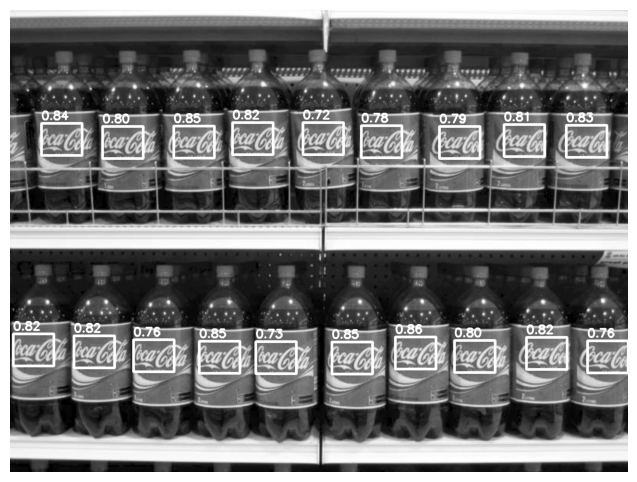

In [6]:
# Tomamos el mejor template y lo corremos sobre la imagen
template = processed_patterns[best_template_idx]

w, h = template.shape[::-1]
res = cv.matchTemplate(img_gray,template,cv.TM_CCOEFF_NORMED)

# Ajustamos el umbral de coincidencia
threshold = 0.7

# Armamos los bounding boxes
loc = np.where( res >= threshold)

boxes = []
conf_scores = []

for pt in zip(*loc[::-1]):
    
    # Tomo el nivel de confiaza de cada punto
    conf_score = float(res[pt[1], pt[0]])
    boxes.append([pt[0], pt[1], w, h])
    conf_scores.append(conf_score)

# Para que no se superpongan niveles de confianza aplico Non-Maximum-Suppression (NMS)
indices = cv.dnn.NMSBoxes(boxes, conf_scores, score_threshold=threshold, nms_threshold=0.3)
for i in indices:
    i = int(i)
    x, y, bw, bh = boxes[i]
    conf_score = conf_scores[i]

    cv.rectangle(img_gray, (x, y), (x + bw, y + bh), 255, 6)
    cv.putText(img_gray, f"{conf_score:.2f}", (x, y - 10),
               cv.FONT_HERSHEY_SIMPLEX, 1, 255, 3)

plt.figure(figsize=(8,6))
plt.imshow(img_gray, cmap='gray')
plt.axis("off")
plt.show()